# Waymo Open Dataset — Scenario Visualizer
Reads scenario TFRecord files (no TensorFlow required) and visualizes map features and agent trajectories.

In [1]:
"""Setup: compile Waymo proto definitions (runs once, cached on disk)."""
import os, sys, textwrap
from pathlib import Path

PROTO_ROOT = Path('waymo_protos')
PROTO_DIR  = PROTO_ROOT / 'waymo_open_dataset' / 'protos'
PROTO_DIR.mkdir(parents=True, exist_ok=True)

# ── map.proto ──────────────────────────────────────────────────────────────
(PROTO_DIR / 'map.proto').write_text(textwrap.dedent("""
    syntax = "proto2";
    package waymo.open_dataset;

    message Map {
      repeated MapFeature map_features = 1;
      repeated DynamicState dynamic_states = 2;
    }
    message DynamicState {
      optional double timestamp_seconds = 1;
      repeated TrafficSignalLaneState lane_states = 2;
    }
    message TrafficSignalLaneState {
      optional int64 lane = 1;
      enum State {
        LANE_STATE_UNKNOWN         = 0;
        LANE_STATE_ARROW_STOP      = 1;
        LANE_STATE_ARROW_CAUTION   = 2;
        LANE_STATE_ARROW_GO        = 3;
        LANE_STATE_STOP            = 4;
        LANE_STATE_CAUTION         = 5;
        LANE_STATE_GO              = 6;
        LANE_STATE_FLASHING_STOP   = 7;
        LANE_STATE_FLASHING_CAUTION = 8;
      }
      optional State state = 2;
      optional MapPoint stop_point = 3;
    }
    message MapFeature {
      optional int64 id = 1;
      oneof feature_data {
        LaneCenter lane      = 3;
        RoadLine   road_line = 4;
        RoadEdge   road_edge = 5;
        StopSign   stop_sign = 7;
        Crosswalk  crosswalk = 8;
        SpeedBump  speed_bump = 9;
        Driveway   driveway   = 10;
      }
    }
    message MapPoint {
      optional double x = 1;
      optional double y = 2;
      optional double z = 3;
    }
    message BoundarySegment {
      optional int32 lane_start_index   = 1;
      optional int32 lane_end_index     = 2;
      optional int64 boundary_feature_id = 3;
      optional RoadLine.RoadLineType boundary_type = 4;
    }
    message LaneNeighbor {
      optional int64 feature_id        = 1;
      optional int32 self_start_index  = 2;
      optional int32 self_end_index    = 3;
      optional int32 neighbor_start_index = 4;
      optional int32 neighbor_end_index   = 5;
      repeated BoundarySegment boundaries = 6;
    }
    message LaneCenter {
      optional double speed_limit_mph = 1;
      enum LaneType {
        TYPE_UNDEFINED     = 0;
        TYPE_FREEWAY       = 1;
        TYPE_SURFACE_STREET = 2;
        TYPE_BIKE_LANE     = 3;
      }
      optional LaneType type          = 2;
      optional bool      interpolating = 3;
      repeated MapPoint  polyline      = 8;
      repeated int64     entry_lanes   = 9  [packed = true];
      repeated int64     exit_lanes    = 10 [packed = true];
      repeated BoundarySegment left_boundaries  = 13;
      repeated BoundarySegment right_boundaries = 14;
      repeated LaneNeighbor    left_neighbors   = 11;
      repeated LaneNeighbor    right_neighbors  = 12;
    }
    message RoadEdge {
      enum RoadEdgeType {
        TYPE_UNKNOWN           = 0;
        TYPE_ROAD_EDGE_BOUNDARY = 1;
        TYPE_ROAD_EDGE_MEDIAN  = 2;
      }
      optional RoadEdgeType type = 1;
      repeated MapPoint polyline = 2;
    }
    message RoadLine {
      enum RoadLineType {
        TYPE_UNKNOWN              = 0;
        TYPE_BROKEN_SINGLE_WHITE  = 1;
        TYPE_SOLID_SINGLE_WHITE   = 2;
        TYPE_SOLID_DOUBLE_WHITE   = 3;
        TYPE_BROKEN_SINGLE_YELLOW = 4;
        TYPE_BROKEN_DOUBLE_YELLOW = 5;
        TYPE_SOLID_SINGLE_YELLOW  = 6;
        TYPE_SOLID_DOUBLE_YELLOW  = 7;
        TYPE_PASSING_DOUBLE_YELLOW = 8;
      }
      optional RoadLineType type = 1;
      repeated MapPoint polyline = 2;
    }
    message StopSign  { repeated int64 lane = 1; optional MapPoint position = 2; }
    message Crosswalk { repeated MapPoint polygon = 1; }
    message SpeedBump { repeated MapPoint polygon = 1; }
    message Driveway  { repeated MapPoint polygon = 1; }
""").lstrip())

# ── scenario.proto (camera/lidar fields omitted — not needed for viz) ───────
(PROTO_DIR / 'scenario.proto').write_text(textwrap.dedent("""
    syntax = "proto2";
    package waymo.open_dataset;
    import "waymo_open_dataset/protos/map.proto";

    message ObjectState {
      optional double center_x   = 2;
      optional double center_y   = 3;
      optional double center_z   = 4;
      optional float  length     = 5;
      optional float  width      = 6;
      optional float  height     = 7;
      optional float  heading    = 8;
      optional float  velocity_x = 9;
      optional float  velocity_y = 10;
      optional bool   valid      = 11;
    }
    message Track {
      enum ObjectType {
        TYPE_UNSET      = 0;
        TYPE_VEHICLE    = 1;
        TYPE_PEDESTRIAN = 2;
        TYPE_CYCLIST    = 3;
        TYPE_OTHER      = 4;
      }
      optional int32      id          = 1;
      optional ObjectType object_type = 2;
      repeated ObjectState states     = 3;
    }
    message DynamicMapState {
      repeated TrafficSignalLaneState lane_states = 1;
    }
    message RequiredPrediction {
      enum DifficultyLevel { NONE = 0; LEVEL_1 = 1; LEVEL_2 = 2; }
      optional int32           track_index = 1;
      optional DifficultyLevel difficulty  = 2;
    }
    message Scenario {
      reserved 9;
      optional string scenario_id        = 5;
      repeated double timestamps_seconds = 1;
      optional int32  current_time_index = 10;
      repeated Track  tracks             = 2;
      repeated DynamicMapState dynamic_map_states = 7;
      repeated MapFeature      map_features       = 8;
      optional int32           sdc_track_index    = 6;
      repeated int32           objects_of_interest = 4;
      repeated RequiredPrediction tracks_to_predict = 11;
    }
""").lstrip())

# ── compile protos if generated files are missing ──────────────────────────
gen_map      = PROTO_ROOT / 'waymo_open_dataset' / 'protos' / 'map_pb2.py'
gen_scenario = PROTO_ROOT / 'waymo_open_dataset' / 'protos' / 'scenario_pb2.py'

if not gen_map.exists() or not gen_scenario.exists():
    from grpc_tools import protoc
    ret = protoc.main([
        'grpc_tools.protoc',
        f'-I{PROTO_ROOT}',
        f'--python_out={PROTO_ROOT}',
        str(PROTO_DIR / 'map.proto'),
        str(PROTO_DIR / 'scenario.proto'),
    ])
    assert ret == 0, 'protoc compilation failed'

    # Create __init__.py files so the package is importable
    for d in [
        PROTO_ROOT / 'waymo_open_dataset',
        PROTO_ROOT / 'waymo_open_dataset' / 'protos',
    ]:
        (d / '__init__.py').touch()

if str(PROTO_ROOT) not in sys.path:
    sys.path.insert(0, str(PROTO_ROOT))

from waymo_open_dataset.protos import scenario_pb2, map_pb2
print('Proto compilation OK')

Proto compilation OK


In [2]:
"""Pure-Python TFRecord reader — no TensorFlow needed."""
import struct, zlib
from typing import Iterator

def iter_tfrecords(path: str) -> Iterator[bytes]:
    """Yield raw bytes for each record in a TFRecord file."""
    with open(path, 'rb') as f:
        while True:
            len_bytes = f.read(8)
            if len(len_bytes) == 0:
                return
            length = struct.unpack('<Q', len_bytes)[0]
            f.read(4)            # skip masked CRC of length
            data = f.read(length)
            f.read(4)            # skip masked CRC of data
            yield data

def load_scenario(record_bytes: bytes) -> scenario_pb2.Scenario:
    s = scenario_pb2.Scenario()
    s.ParseFromString(record_bytes)
    return s

print('TFRecord reader ready')

TFRecord reader ready


In [3]:
"""Configuration — adjust paths and indices here."""
import glob as _glob

DATA_ROOT  = '/depot/ziran/data/shared/waymo/scenario'
SPLIT      = 'validation'   # 'training' | 'validation' | 'testing'

tfrecord_files = sorted(_glob.glob(f'{DATA_ROOT}/{SPLIT}/{SPLIT}.tfrecord-*'))
print(f'Found {len(tfrecord_files)} TFRecord files for split "{SPLIT}"')

FILE_IDX     = 0   # which TFRecord file to open
SCENARIO_IDX = 5   # which scenario within that file

Found 150 TFRecord files for split "validation"


In [4]:
"""Load one scenario."""
chosen_file = tfrecord_files[FILE_IDX]
print(f'Reading: {chosen_file}')

scenario = None
for i, record in enumerate(iter_tfrecords(chosen_file)):
    if i == SCENARIO_IDX:
        scenario = load_scenario(record)
        break

assert scenario is not None

n_steps   = len(scenario.timestamps_seconds)
n_tracks  = len(scenario.tracks)
n_map     = len(scenario.map_features)
cur_t     = scenario.current_time_index

print(f'Scenario ID : {scenario.scenario_id}')
print(f'Timesteps   : {n_steps}  (current = {cur_t})')
print(f'Tracks      : {n_tracks}')
print(f'Map features: {n_map}')
print(f'SDC index   : {scenario.sdc_track_index}')

Reading: /depot/ziran/data/shared/waymo/scenario/validation/validation.tfrecord-00000-of-00150
Scenario ID : 8648f5e79d851915
Timesteps   : 91  (current = 10)
Tracks      : 84
Map features: 472
SDC index   : 83


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
%matplotlib widget

In [6]:
"""Helpers for extracting map geometry."""

def poly_xy(points):
    xs = [p.x for p in points]
    ys = [p.y for p in points]
    return xs, ys

LANE_TYPE_COLOR = {
    map_pb2.LaneCenter.TYPE_FREEWAY        : '#888888',
    map_pb2.LaneCenter.TYPE_SURFACE_STREET : '#aaaaaa',
    map_pb2.LaneCenter.TYPE_BIKE_LANE      : '#66bb66',
    map_pb2.LaneCenter.TYPE_UNDEFINED      : '#cccccc',
}

ROAD_LINE_STYLE = {
    map_pb2.RoadLine.TYPE_BROKEN_SINGLE_WHITE : dict(color='white',  lw=0.6, ls='--'),
    map_pb2.RoadLine.TYPE_SOLID_SINGLE_WHITE  : dict(color='white',  lw=0.8, ls='-'),
    map_pb2.RoadLine.TYPE_SOLID_DOUBLE_WHITE  : dict(color='white',  lw=1.2, ls='-'),
    map_pb2.RoadLine.TYPE_BROKEN_SINGLE_YELLOW: dict(color='yellow', lw=0.6, ls='--'),
    map_pb2.RoadLine.TYPE_SOLID_SINGLE_YELLOW : dict(color='yellow', lw=0.8, ls='-'),
    map_pb2.RoadLine.TYPE_SOLID_DOUBLE_YELLOW : dict(color='yellow', lw=1.2, ls='-'),
    map_pb2.RoadLine.TYPE_BROKEN_DOUBLE_YELLOW: dict(color='yellow', lw=0.8, ls='--'),
    map_pb2.RoadLine.TYPE_PASSING_DOUBLE_YELLOW: dict(color='yellow', lw=0.8, ls='-.'),
    map_pb2.RoadLine.TYPE_UNKNOWN             : dict(color='gray',   lw=0.4, ls=':'),
}

print('Map helpers ready')

Map helpers ready


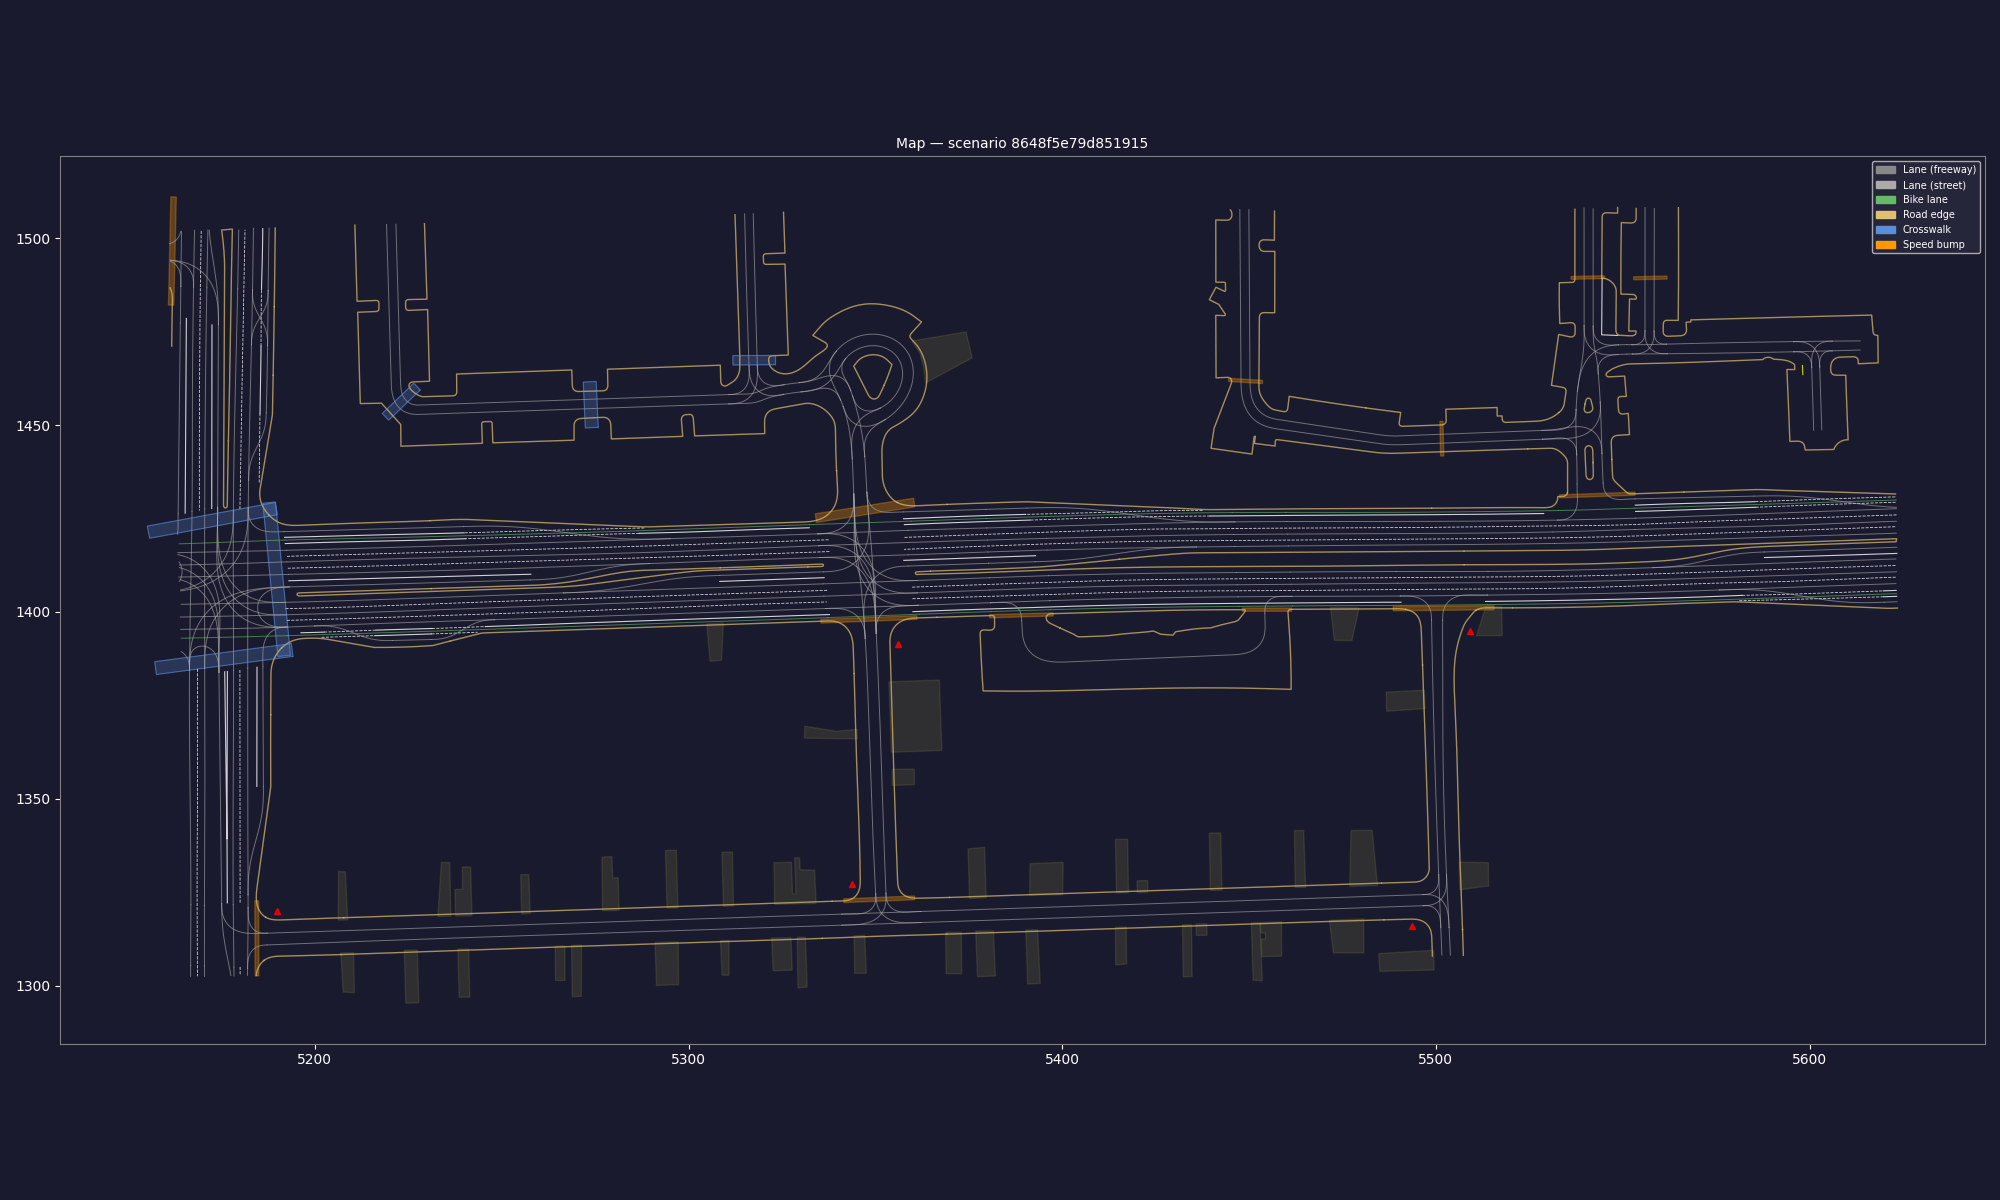

In [13]:
"""Visualize map features."""
fig, ax = plt.subplots(figsize=(20, 12))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.set_aspect('equal')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('gray')
ax.set_title(f'Map — scenario {scenario.scenario_id}', color='white', fontsize=10)

for feat in scenario.map_features:
    kind = feat.WhichOneof('feature_data')
    if kind == 'lane':
        xs, ys = poly_xy(feat.lane.polyline)
        c = LANE_TYPE_COLOR.get(feat.lane.type, '#cccccc')
        ax.plot(xs, ys, color=c, lw=0.7, alpha=0.6)

    elif kind == 'road_line':
        xs, ys = poly_xy(feat.road_line.polyline)
        st = ROAD_LINE_STYLE.get(feat.road_line.type,
                                  dict(color='gray', lw=0.4, ls=':'))
        ax.plot(xs, ys, alpha=0.8, **st)

    elif kind == 'road_edge':
        xs, ys = poly_xy(feat.road_edge.polyline)
        ax.plot(xs, ys, color='#e0c070', lw=1.0, alpha=0.7)

    elif kind == 'crosswalk':
        xs, ys = poly_xy(feat.crosswalk.polygon)
        xs.append(xs[0]); ys.append(ys[0])   # close polygon
        ax.fill(xs, ys, color='#5b8dd9', alpha=0.25)
        ax.plot(xs, ys, color='#5b8dd9', lw=0.6, alpha=0.6)

    elif kind == 'speed_bump':
        xs, ys = poly_xy(feat.speed_bump.polygon)
        xs.append(xs[0]); ys.append(ys[0])
        ax.fill(xs, ys, color='#ff9900', alpha=0.3)

    elif kind == 'stop_sign':
        p = feat.stop_sign.position
        ax.plot(p.x, p.y, 'r^', ms=4, alpha=0.8)

    elif kind == 'driveway':
        xs, ys = poly_xy(feat.driveway.polygon)
        xs.append(xs[0]); ys.append(ys[0])
        ax.fill(xs, ys, color='#888844', alpha=0.2)

# Legend
legend_items = [
    mpatches.Patch(color='#888888', label='Lane (freeway)'),
    mpatches.Patch(color='#aaaaaa', label='Lane (street)'),
    mpatches.Patch(color='#66bb66', label='Bike lane'),
    mpatches.Patch(color='#e0c070', label='Road edge'),
    mpatches.Patch(color='#5b8dd9', label='Crosswalk'),
    mpatches.Patch(color='#ff9900', label='Speed bump'),
]
ax.legend(handles=legend_items, loc='upper right',
          facecolor='#2a2a3e', labelcolor='white', fontsize=7)
plt.tight_layout()
plt.show()

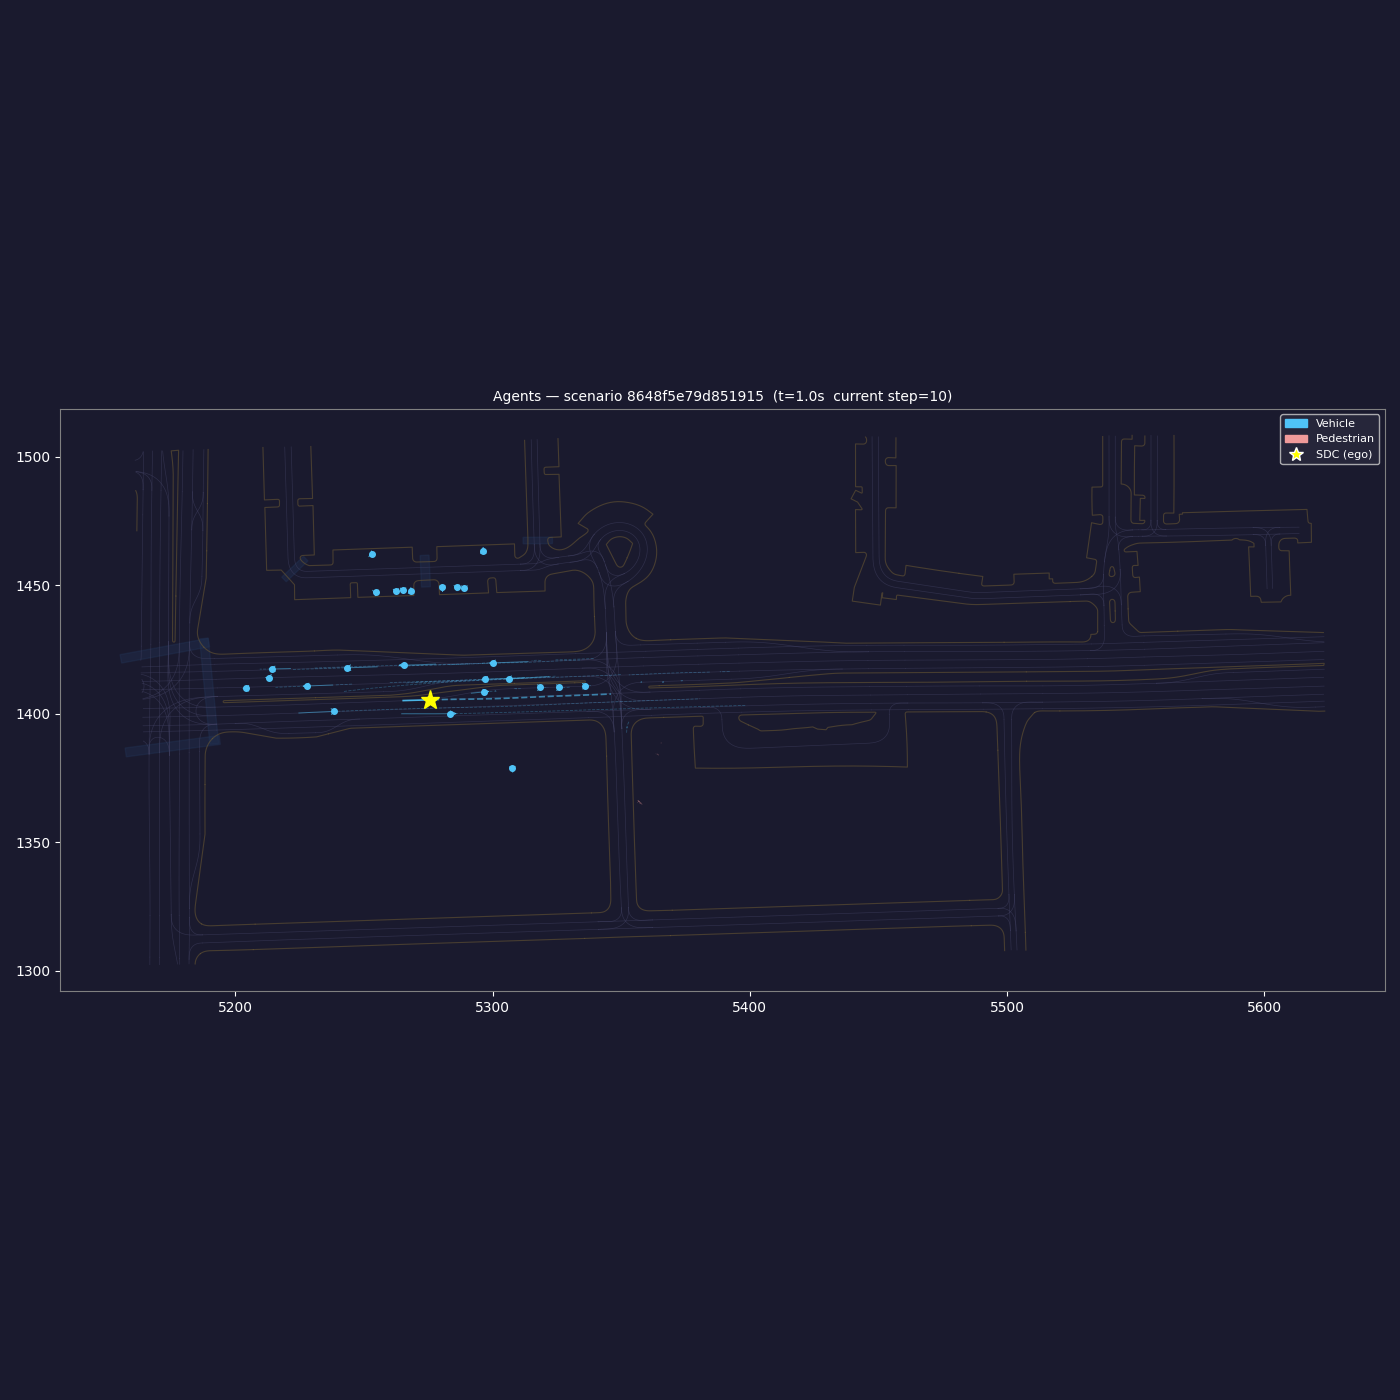

In [8]:
"""Visualize agent trajectories overlaid on the map."""

AGENT_COLOR = {
    1: '#4fc3f7',   # vehicle
    2: '#ef9a9a',   # pedestrian
    3: '#a5d6a7',   # cyclist
    4: '#fff176',   # other
    0: '#cccccc',   # unset
}
AGENT_LABEL = {1: 'Vehicle', 2: 'Pedestrian', 3: 'Cyclist', 4: 'Other'}

sdc_idx = scenario.sdc_track_index

fig, ax = plt.subplots(figsize=(14, 14))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.set_aspect('equal')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('gray')
ax.set_title(f'Agents — scenario {scenario.scenario_id}  '
             f'(t={scenario.timestamps_seconds[cur_t]:.1f}s  current step={cur_t})',
             color='white', fontsize=10)

# ── draw map (light) ────────────────────────────────────────────────────────
for feat in scenario.map_features:
    kind = feat.WhichOneof('feature_data')
    if kind == 'lane':
        xs, ys = poly_xy(feat.lane.polyline)
        ax.plot(xs, ys, color='#444466', lw=0.5, alpha=0.5)
    elif kind == 'road_edge':
        xs, ys = poly_xy(feat.road_edge.polyline)
        ax.plot(xs, ys, color='#665533', lw=0.8, alpha=0.6)
    elif kind == 'crosswalk':
        xs, ys = poly_xy(feat.crosswalk.polygon)
        xs.append(xs[0]); ys.append(ys[0])
        ax.fill(xs, ys, color='#223355', alpha=0.4)

# ── draw agent tracks ───────────────────────────────────────────────────────
n_interp = cur_t + 1          # number of past+present steps
plotted_types = set()

for i, track in enumerate(scenario.tracks):
    states = track.states
    obj_type = track.object_type
    color = AGENT_COLOR.get(obj_type, '#cccccc')
    is_sdc = (i == sdc_idx)

    # valid state mask
    xs_all = np.array([s.center_x if s.valid else np.nan for s in states])
    ys_all = np.array([s.center_y if s.valid else np.nan for s in states])

    # past trajectory
    xs_past = xs_all[:n_interp]
    ys_past = ys_all[:n_interp]
    ax.plot(xs_past, ys_past,
            color=color, lw=1.2 if is_sdc else 0.7,
            alpha=0.9 if is_sdc else 0.5,
            zorder=3 if is_sdc else 2)

    # future trajectory (dashed)
    xs_fut = xs_all[n_interp:]
    ys_fut = ys_all[n_interp:]
    ax.plot(xs_fut, ys_fut,
            color=color, lw=1.2 if is_sdc else 0.6,
            alpha=0.6 if is_sdc else 0.3,
            ls='--', zorder=3 if is_sdc else 2)

    # bounding box at current time
    st = states[cur_t]
    if st.valid:
        if is_sdc:
            marker = '*'
            ms     = 14
            mcolor = '#ffff00'
            mz     = 5
        else:
            marker = 'o'
            ms     = 4 if obj_type == 1 else 3
            mcolor = color
            mz     = 4

        ax.plot(st.center_x, st.center_y, marker=marker,
                color=mcolor, ms=ms, zorder=mz)

        # heading arrow
        hw = st.heading
        arrow_len = max(st.length * 0.6, 1.5)
        ax.annotate('', xy=(st.center_x + arrow_len * np.cos(hw),
                            st.center_y + arrow_len * np.sin(hw)),
                    xytext=(st.center_x, st.center_y),
                    arrowprops=dict(arrowstyle='->', color=mcolor,
                                   lw=1.2 if is_sdc else 0.6),
                    zorder=mz)

    plotted_types.add(obj_type)

# ── legend ──────────────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color=AGENT_COLOR[t], label=AGENT_LABEL.get(t, str(t)))
    for t in sorted(plotted_types) if t in AGENT_LABEL
]
legend_items.append(
    plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='yellow',
               markersize=10, label='SDC (ego)', linestyle='none'))
ax.legend(handles=legend_items, loc='upper right',
          facecolor='#2a2a3e', labelcolor='white', fontsize=8)

plt.tight_layout()
plt.show()

In [9]:
"""Traffic signal states at the current timestep."""
from waymo_open_dataset.protos.map_pb2 import TrafficSignalLaneState as TSLS

# Build a lookup: lane_id → (x, y) from map features
lane_center_pos = {}
for feat in scenario.map_features:
    if feat.WhichOneof('feature_data') == 'lane':
        pts = feat.lane.polyline
        if pts:
            mid = pts[len(pts) // 2]
            lane_center_pos[feat.id] = (mid.x, mid.y)

SIGNAL_COLOR = {
    TSLS.LANE_STATE_STOP           : 'red',
    TSLS.LANE_STATE_ARROW_STOP     : 'red',
    TSLS.LANE_STATE_FLASHING_STOP  : 'darkred',
    TSLS.LANE_STATE_CAUTION        : 'yellow',
    TSLS.LANE_STATE_ARROW_CAUTION  : 'yellow',
    TSLS.LANE_STATE_FLASHING_CAUTION: 'orange',
    TSLS.LANE_STATE_GO             : 'lime',
    TSLS.LANE_STATE_ARROW_GO       : 'lime',
    TSLS.LANE_STATE_UNKNOWN        : 'gray',
}

dms = scenario.dynamic_map_states[cur_t]
if not dms.lane_states:
    print('No traffic signal data at this timestep.')
else:
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_facecolor('#1a1a2e')
    fig.patch.set_facecolor('#1a1a2e')
    ax.set_aspect('equal')
    ax.tick_params(colors='white')
    ax.set_title('Traffic signals at current timestep', color='white', fontsize=10)

    for feat in scenario.map_features:
        if feat.WhichOneof('feature_data') == 'lane':
            xs, ys = poly_xy(feat.lane.polyline)
            ax.plot(xs, ys, color='#444466', lw=0.5, alpha=0.5)
        elif feat.WhichOneof('feature_data') == 'road_edge':
            xs, ys = poly_xy(feat.road_edge.polyline)
            ax.plot(xs, ys, color='#665533', lw=0.8, alpha=0.6)

    for ls in dms.lane_states:
        c = SIGNAL_COLOR.get(ls.state, 'gray')
        if ls.stop_point.IsInitialized() and ls.stop_point.x != 0:
            ax.plot(ls.stop_point.x, ls.stop_point.y, 'o',
                    color=c, ms=8, zorder=5)
        elif ls.lane in lane_center_pos:
            x, y = lane_center_pos[ls.lane]
            ax.plot(x, y, 'o', color=c, ms=8, zorder=5)

    legend_items = [
        mpatches.Patch(color='red',  label='Stop'),
        mpatches.Patch(color='yellow', label='Caution'),
        mpatches.Patch(color='lime', label='Go'),
        mpatches.Patch(color='gray', label='Unknown'),
    ]
    ax.legend(handles=legend_items, loc='upper right',
              facecolor='#2a2a3e', labelcolor='white', fontsize=8)
    plt.tight_layout()
    plt.show()

No traffic signal data at this timestep.


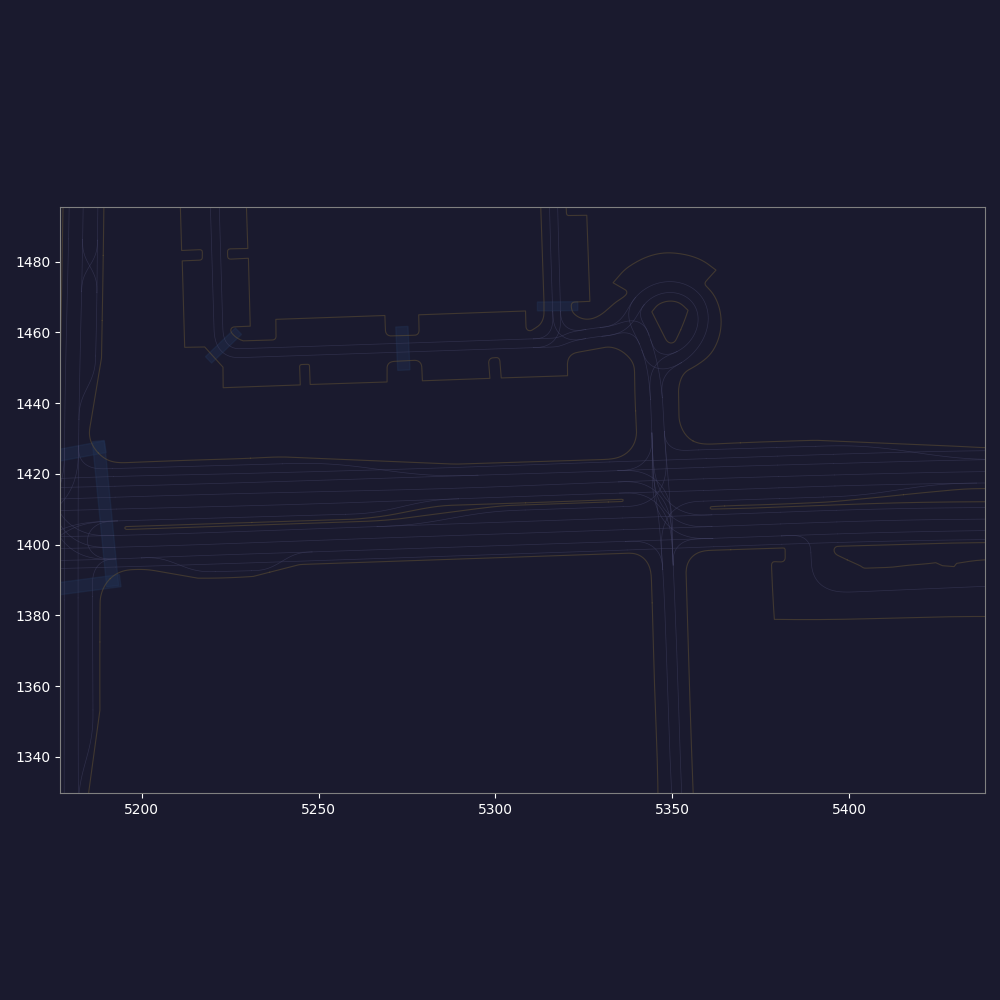

In [10]:
"""Animate agent trajectories through all timesteps."""
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.set_aspect('equal')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('gray')

# Static map background
for feat in scenario.map_features:
    kind = feat.WhichOneof('feature_data')
    if kind == 'lane':
        xs, ys = poly_xy(feat.lane.polyline)
        ax.plot(xs, ys, color='#444466', lw=0.5, alpha=0.5)
    elif kind == 'road_edge':
        xs, ys = poly_xy(feat.road_edge.polyline)
        ax.plot(xs, ys, color='#665533', lw=0.8, alpha=0.5)
    elif kind == 'crosswalk':
        xs, ys = poly_xy(feat.crosswalk.polygon)
        xs.append(xs[0]); ys.append(ys[0])
        ax.fill(xs, ys, color='#223355', alpha=0.4)

# Pre-extract all agent positions
n_t = len(scenario.timestamps_seconds)
agent_data = []
for i, track in enumerate(scenario.tracks):
    xs = np.array([s.center_x if s.valid else np.nan for s in track.states])
    ys = np.array([s.center_y if s.valid else np.nan for s in track.states])
    hs = np.array([s.heading  if s.valid else 0.0    for s in track.states])
    vs = np.array([s.valid                           for s in track.states])
    agent_data.append((xs, ys, hs, vs, track.object_type, i == sdc_idx))

# Create scatter/quiver placeholders
scatter_handles = {}
for obj_type, color in AGENT_COLOR.items():
    scatter_handles[obj_type] = ax.plot([], [], 'o', color=color,
                                         ms=4, alpha=0.8, zorder=4)[0]
sdc_handle = ax.plot([], [], '*', color='yellow', ms=12, zorder=5)[0]
time_text  = ax.text(0.02, 0.97, '', transform=ax.transAxes,
                     color='white', fontsize=9, va='top')

# Set axis limits from first valid positions
all_x = [d[0] for d in agent_data]
all_y = [d[1] for d in agent_data]
flat_x = np.concatenate(all_x)
flat_y = np.concatenate(all_y)
valid  = ~np.isnan(flat_x)
margin = 20
ax.set_xlim(flat_x[valid].min() - margin, flat_x[valid].max() + margin)
ax.set_ylim(flat_y[valid].min() - margin, flat_y[valid].max() + margin)

def update(t):
    by_type = {k: ([], []) for k in AGENT_COLOR}
    sdc_pos = ([], [])
    for xs, ys, hs, vs, obj_type, is_sdc in agent_data:
        if vs[t]:
            if is_sdc:
                sdc_pos[0].append(xs[t])
                sdc_pos[1].append(ys[t])
            else:
                by_type[obj_type][0].append(xs[t])
                by_type[obj_type][1].append(ys[t])
    for obj_type, (bx, by) in by_type.items():
        scatter_handles[obj_type].set_data(bx, by)
    sdc_handle.set_data(sdc_pos[0], sdc_pos[1])
    ts = scenario.timestamps_seconds[t]
    label = 'PAST' if t < cur_t else ('CURRENT' if t == cur_t else 'FUTURE')
    time_text.set_text(f't={ts:.2f}s  step {t}/{n_t-1}  [{label}]')
    return list(scatter_handles.values()) + [sdc_handle, time_text]

anim = animation.FuncAnimation(fig, update, frames=n_t,
                                interval=100, blit=True)
plt.tight_layout()
plt.show()